## Code to plot zonal average mean, variance, skewness of certain fields

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as mp
import pandas as pd
from scipy.stats import skew

from datetime import datetime as dt
import os
import glob as gb

In [10]:
# Set up case/data variables

#dir_root = '/glade/campaign/cgd/amp/amwg/climo/'
dir_root = '/glade/derecho/scratch/rneale/archive/'
dir_root2 = '/glade/p/cgd/amp/people/hannay/amwg/climo2/'

dir_obs = '/glade/campaign/cgd/amp/amwg/amwg_data/obs_data/'
dir_tobs = '/glade/campaign/cgd/amp/rneale/data/TRMM/daily/1deg/'
dir_gobs = '/glade/work/rneale/data/GPCP/'
dir_fig = '/glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/'


ldiff_ctrl = True # Difference compared to the control?

#seas = np.array(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec','DJF','MAM','JJA','SON']) # If 2 seasons does 2 columns, if 1 does successive rows.
#seas = np.array(['JJA'])

var_name = 'PRECC'

fig_sub = 'AMWG25_zm_var_'

rmask = 1   # 1-Global, 2-Land, 3-Ocean

#case_desc =  ['TRMM','CESM3','CESM2']
#time_start  = [2000,105,501]
#time_end    = [2009,110,510]

#case_rnames = ['TRMM','b.e30_beta04.BLT1850.ne30_t232_wgx3.121','CESM2_piControl']

case_desc =  ['CESM2','CESM3','GPCP','TRMM']
time_start  = [501,105,2000,2000]
time_end    = [510,110,2009,2009]

case_rnames = ['CESM2_piControl','b.e30_beta04.BLT1850.ne30_t232_wgx3.121','GPCP','TRMM']


case_desc =  np.array(case_desc)
case_rname =  np.array(case_rnames)
#case_start =  np.float(case_rnames)


CESM2 - yrs (501-510)
/glade/derecho/scratch/rneale/archive/CESM2_piControl/tseries/CESM2_piControl_dmeans_ts_PRECC.nc


/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/xarray/conventions.py:287: SerializationWarning: variable 'prc' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: invalid value encountered in divide
  nval = ((n - 1.0) * n)**0.5 / (n - 2.0) * m3 / m2**1.5


Plotting ...

CESM3 - yrs (105-110)
/glade/derecho/scratch/rneale/archive/b.e30_beta04.BLT1850.ne30_t232_wgx3.121/tseries/b.e30_beta04.BLT1850.ne30_t232_wgx3.121_dmeans_ts_PRECC.nc
Plotting ...

GPCP - yrs (2000-2009)
/glade/work/rneale/data/GPCP/GPCP_dmeans_ts_PRECT.nc
Plotting ...

TRMM - yrs (2000-2009)
/glade/campaign/cgd/amp/rneale/data/TRMM/daily/1deg/3B42.1998-2013.daily.1deg.v7.nc
Plotting ...


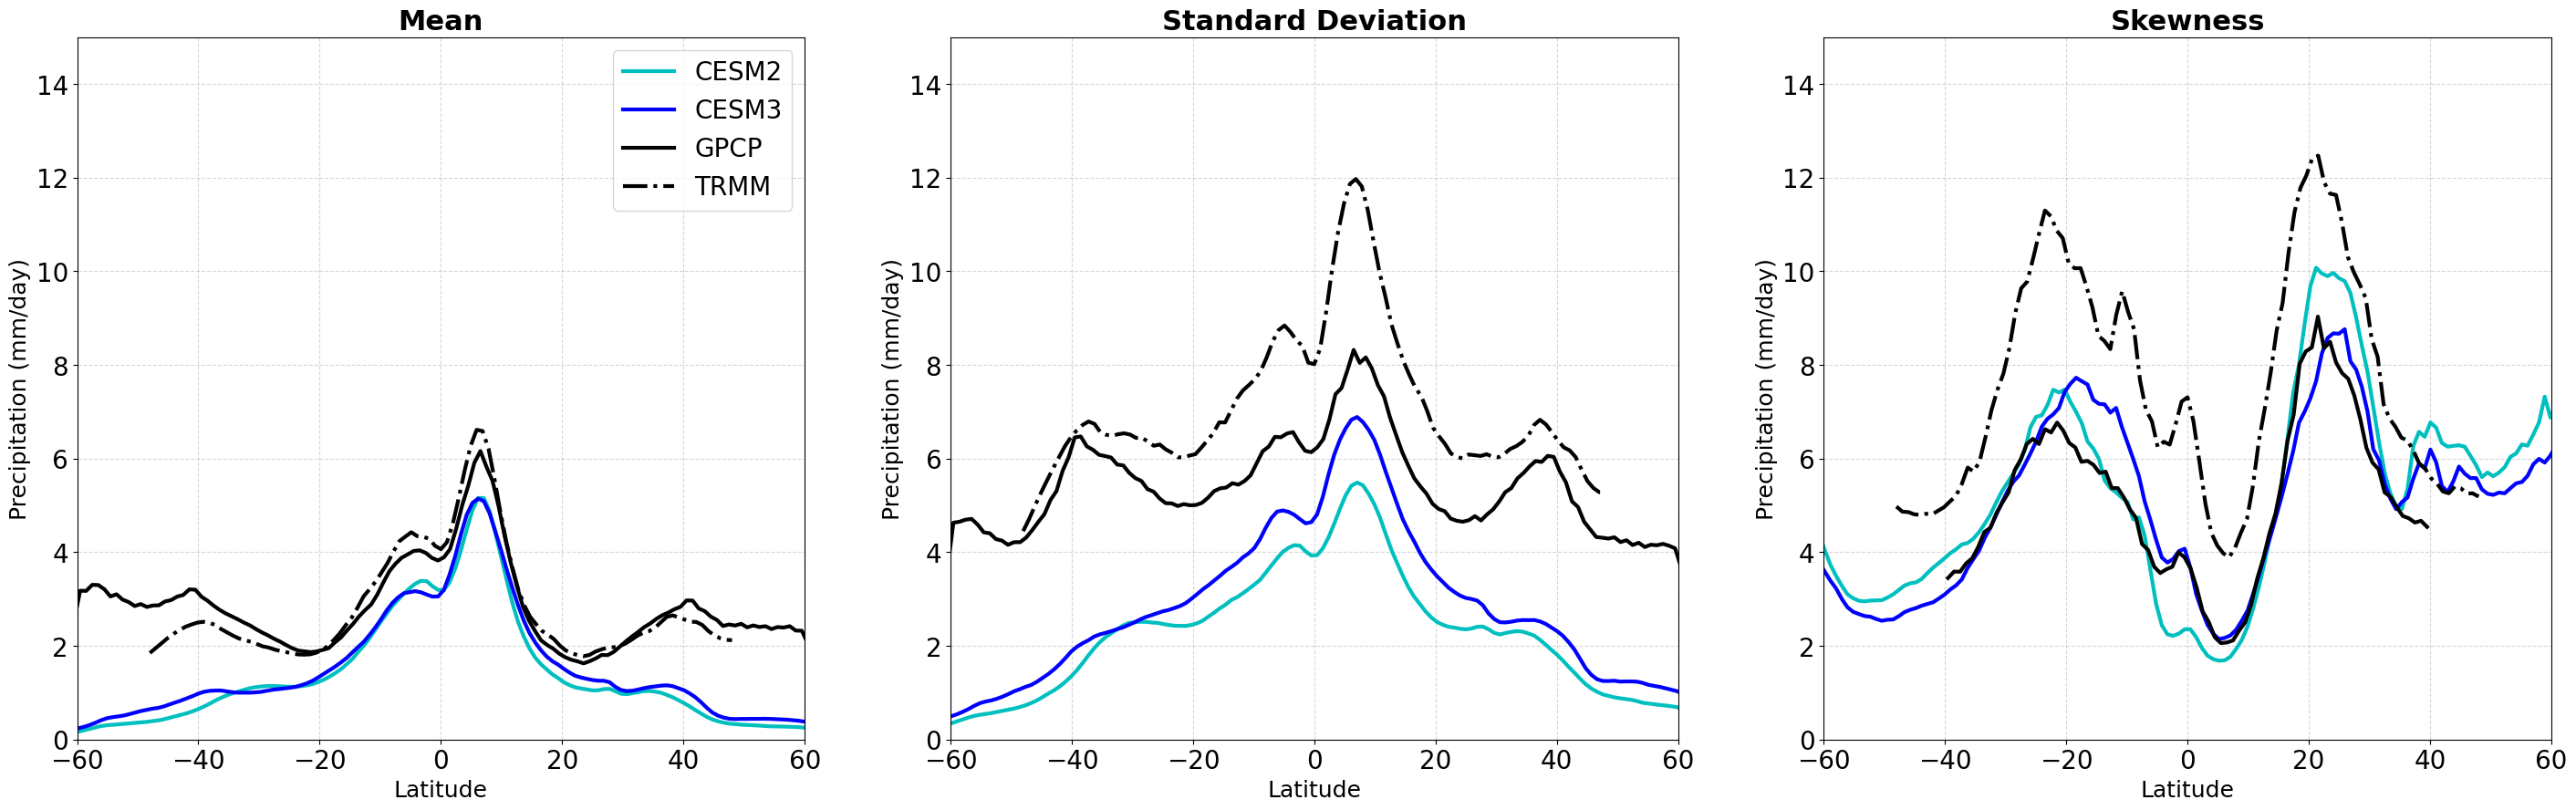

In [11]:
# Plotting

fig, ax= mp.subplots(nrows=1, ncols=3, figsize=[35, 10])

fsize = 18
lwidth = 3


# Some dta options

fig_reg = '_global'
lfrac_hist = '/glade/derecho/scratch/rneale/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001/run/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001.cam.h0a.2006-12.nc'

# Grab runs and data


ts_suff = '_dmeans_ts_'+var_name


# Do we need to mask according to a land-sea mask?
    
if rmask > 1 :

    # Just grab an existing h0 field LANDFRAC
    ds_lf =  xr.open_dataset(lfrac_hist,engine='netcdf4')
    clandfrac = ds_lf.LANDFRAC
    clandfrac = clandfrac.squeeze()



for icase,case in enumerate(case_desc):

    case_rname = case_rnames[icase]

   

    tstrt = time_start[icase]
    tend =  time_end[icase]     

    print()
    print(case+' - yrs ('+str(tstrt)+'-'+str(tend)+')')

    
    match case:
    
        case 'TRMM': 
            print(file_in := dir_tobs+'3B42.1998-2013.daily.1deg.v7.nc')
            ds_in =  xr.open_dataset(file_in,engine='netcdf4')
            
            da_in = ds_in.precip.sel(time=slice(str(tstrt),str(tend)))

            lcol = 'k' ; lsty='-.'
        
        case 'GPCP' :
            print(file_in := dir_gobs+'GPCP_dmeans_ts_PRECT.nc')
            ds_in =  xr.open_dataset(file_in,engine='netcdf4')
            da_in = ds_in.PRECT.sel(time=slice(str(tstrt),str(tend)))

            lcol = 'k' ; lsty='-'
    
        case 'CESM3' :
            print(file_in := dir_root+case_rname+'/tseries/'+case_rname+ts_suff+'.nc')
            ds_in = xr.open_dataset(file_in,engine='netcdf4')
         
            tt_yr0 = (ds_in.time.dt.year >= tstrt)
            tt_yr1 = (ds_in.time.dt.year <= tend)
            
            ds_in = ds_in.where(tt_yr0 & tt_yr1,drop=True)
            da_in = 86400.*1000.*ds_in[var_name]

            lcol = 'b' ; lsty='-'
        
        case 'CESM2':
            print(file_in := dir_root+case_rname+'/tseries/'+case_rname+ts_suff+'.nc')
            ds_in = xr.open_dataset(file_in,engine='netcdf4')
            tt_yr0 = (ds_in.time.dt.year >= tstrt)
            tt_yr1 = (ds_in.time.dt.year <= tend)
            
            ds_in = ds_in.where(tt_yr0 & tt_yr1,drop=True)
            da_in = 86400.*ds_in.prc
            
            lcol = 'c' ; lsty='-'

        case _:
            print(case+' is not recognized')


# Mask?  

    fig_reg = ''
    if rmask > 1:
    
        landfrac = clandfrac.interp_like(da_in)

        
        if rmask == 2: 
            da_in = da_in.where(landfrac > 0.5)  # Mask Land 
            fig_reg = '_land'
        if rmask == 3: 
            da_in = da_in.where(landfrac < 0.5)  # Mask non-Ocean
            fig_reg = '_ocean'
    
# Calculating the time and zonal mean

    da_ave_zm = da_in.mean(dim="time")  
    da_ave_zm = da_ave_zm.mean(dim="lon")  

    da_std_zm = da_in.std(dim="time")  
    da_std_zm = da_std_zm.mean(dim="lon")  

    da_skew = xr.apply_ufunc(
        skew, da_in, input_core_dims=[["time"]], vectorize=True, kwargs={"bias": False}
        )
    
    da_skew_zm = da_skew.mean(dim="lon") 


    print("Plotting ...")
    
    ax[0].plot(da_in.lat,da_ave_zm,linewidth=lwidth,c=lcol,linestyle=lsty)
    ax[1].plot(da_in.lat,da_std_zm,linewidth=lwidth,c=lcol,linestyle=lsty)
    ax[2].plot(da_in.lat,da_skew_zm,linewidth=lwidth,c=lcol,linestyle=lsty)


    for iax,axx in enumerate(ax):

        axx.set_xlabel("Latitude", fontsize=fsize)
        axx.set_ylabel("Precipitation (mm/day)", fontsize=fsize)
        axx.set_xlim([-60.,60])    
        axx.set_ylim([0.,15])  
        axx.grid(True, linestyle="--", alpha=0.5)
        axx.tick_params(axis='both', which='major', labelsize=20)

ax[0].set_title("Mean", fontsize=fsize+4, fontweight="bold")
ax[1].set_title("Standard Deviation", fontsize=fsize+4, fontweight="bold")
ax[2].set_title("Skewness", fontsize=fsize+4, fontweight="bold")

ax[0].legend(case_desc, fontsize=20)

mp.savefig(dir_fig+fig_sub+var_name+fig_reg+'.png', dpi=150)